# COMP315 TFMA Analysis Notebook

This is the official final TFMA notebook for the project.

Required sections included:
- overall TFMA results
- slicing by sex
- slicing by race
- fairness indicator
- counterfactual analysis
- fairness threshold analysis


In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_model_analysis as tfma
import tensorflow_transform as tft

# find repo root from current working directory

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'tfx_pipeline_output_v2').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('could not find repo root from current working directory')

PROJECT_ROOT = find_repo_root(Path.cwd().resolve())
print(f'project root: {PROJECT_ROOT}')


project root: /mnt/c/Users/said_/Documents/COMP-315-Team-Project


In [26]:
# load latest evaluator output
EVAL_BASE_DIR = PROJECT_ROOT / 'tfx_pipeline_output_v2' / 'Evaluator' / 'evaluation'
if not EVAL_BASE_DIR.exists():
    raise FileNotFoundError(f'missing evaluator directory: {EVAL_BASE_DIR}')

run_dirs = sorted(
    [d for d in EVAL_BASE_DIR.iterdir() if d.is_dir() and d.name.isdigit()],
    key=lambda d: int(d.name),
)
if not run_dirs:
    raise FileNotFoundError(f'no eval runs found in: {EVAL_BASE_DIR}')

EVAL_DIR = run_dirs[-1]
eval_result = tfma.load_eval_result(output_path=str(EVAL_DIR))
print(f'loaded eval from: {EVAL_DIR}')


loaded eval from: /mnt/c/Users/said_/Documents/COMP-315-Team-Project/tfx_pipeline_output_v2/Evaluator/evaluation/8


In [27]:
tfma.view.render_slicing_metrics(eval_result)

SlicingMetricsViewer(config={'weightedExamplesColumn': 'example_count'}, data=[{'slice': 'Overall', 'metrics':…

### Interpretation: Overall TFMA Results

The overall metrics show the model has solid baseline classification quality on the evaluation split. This is useful for a global summary, but overall values alone can hide subgroup differences, so slice-based checks are still necessary.


In [28]:
tfma.view.render_slicing_metrics(eval_result, slicing_column='sex')

SlicingMetricsViewer(config={'weightedExamplesColumn': 'example_count'}, data=[{'slice': 'sex:Male', 'metrics'…

### Interpretation: Slicing by Sex

The sex slices show a measurable performance gap between groups. This means the model does not perform equally for this sensitive feature, and fairness should be monitored with subgroup metrics instead of only global averages.


In [29]:
tfma.view.render_slicing_metrics(eval_result, slicing_column='race')

SlicingMetricsViewer(config={'weightedExamplesColumn': 'example_count'}, data=[{'slice': 'race:White', 'metric…

### Interpretation: Slicing by Race

The race slices also show uneven behavior across groups. This confirms that aggregate accuracy can hide subgroup-level issues and supports using slice diagnostics as a standard part of evaluation.


fairness widget not available in this environment, showing parity fallback table


,sex_slice,binary_accuracy,auc
0,Female,0.925790,0.927252
1,Male,0.804227,0.874453


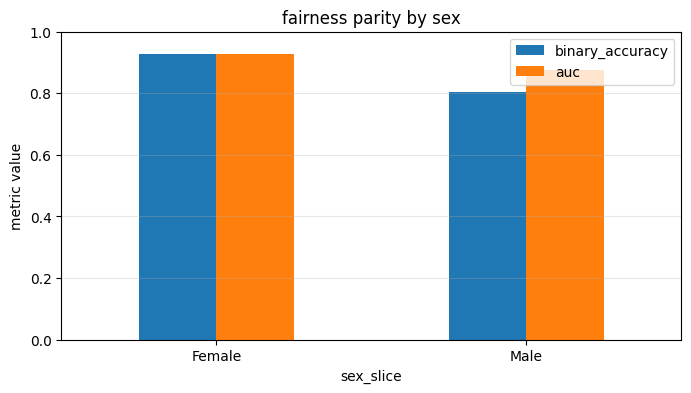

In [30]:
# render fairness output
# use tfma fairness widget if available
rendered = False

if hasattr(tfma.view, 'render_fairness_indicator'):
    try:
        tfma.view.render_fairness_indicator(eval_result, slicing_column='sex')
        rendered = True
    except TypeError:
        tfma.view.render_fairness_indicator(eval_result)
        rendered = True

if not rendered:
    try:
        from tensorflow_model_analysis.addons.fairness.view import widget_view
        try:
            widget_view.render_fairness_indicator(eval_result=eval_result, slicing_column='sex')
            rendered = True
        except TypeError:
            widget_view.render_fairness_indicator(eval_result=eval_result)
            rendered = True
    except Exception:
        rendered = False

if not rendered:
    # fallback parity output for this environment
    from IPython.display import display

    def to_float(value):
        if value is None:
            return None
        if isinstance(value, (int, float, np.floating)):
            return float(value)
        if isinstance(value, dict):
            for key in ['doubleValue', 'floatValue', 'value']:
                if key in value:
                    return float(value[key])
        return None

    def pick_metric(metrics, candidates):
        for key in candidates:
            if key in metrics:
                return to_float(metrics.get(key))

        # some tfma builds store non-string metric keys
        for metric_key, metric_value in metrics.items():
            metric_name = str(metric_key).lower()
            if any(name in metric_name for name in candidates):
                return to_float(metric_value)

        return None

    metrics_by_slice = eval_result.get_metrics_for_all_slices()
    rows = []

    for slice_key, metrics in metrics_by_slice.items():
        if not any(key == 'sex' for key, _ in slice_key):
            continue

        sex_value = next((value for key, value in slice_key if key == 'sex'), None)
        rows.append({
            'sex_slice': sex_value,
            'binary_accuracy': pick_metric(metrics, ['binary_accuracy', 'accuracy']),
            'auc': pick_metric(metrics, ['auc']),
        })

    fairness_df = pd.DataFrame(rows).sort_values('sex_slice').reset_index(drop=True)

    print('fairness widget not available in this environment, showing parity fallback table')
    display(fairness_df)

    if not fairness_df.empty:
        plot_df = fairness_df.set_index('sex_slice')
        plot_cols = [c for c in ['binary_accuracy', 'auc'] if c in plot_df.columns]
        if plot_cols:
            plot_df[plot_cols].plot(kind='bar', figsize=(8, 4), rot=0)
            plt.title('fairness parity by sex')
            plt.ylabel('metric value')
            plt.ylim(0.0, 1.0)
            plt.grid(axis='y', alpha=0.3)
            plt.show()


### Interpretation: Fairness Indicator

The fairness indicator gives a direct comparison of subgroup outcomes at selected thresholds. It supports the slice findings by highlighting where parity gaps remain and where threshold choices can change the observed fairness pattern.


In [31]:
# load model and source data for counterfactual analysis
DATA_PATH = PROJECT_ROOT / 'data' / 'Dataset1_adult' / 'source' / 'adult.csv'
MODEL_ROOT = PROJECT_ROOT / 'tfx_pipeline_output_v2' / 'Trainer' / 'model'

model_runs = sorted(
    [d for d in MODEL_ROOT.iterdir() if d.is_dir() and d.name.isdigit()],
    key=lambda d: int(d.name),
)
if not model_runs:
    raise FileNotFoundError(f'no model runs found in: {MODEL_ROOT}')

latest_model_run = model_runs[-1]
saved_model_pb = next(latest_model_run.rglob('saved_model.pb'), None)
if saved_model_pb is None:
    raise FileNotFoundError(f'no saved_model.pb found under: {latest_model_run}')

MODEL_DIR = saved_model_pb.parent
loaded_model = tf.saved_model.load(str(MODEL_DIR))
serve_fn = loaded_model.signatures['serving_default']
output_key = 'outputs' if 'outputs' in serve_fn.structured_outputs else next(iter(serve_fn.structured_outputs))

df = pd.read_csv(DATA_PATH).copy()

print(f'model dir: {MODEL_DIR}')
print(f'data rows: {len(df)}')


model dir: /mnt/c/Users/said_/Documents/COMP-315-Team-Project/tfx_pipeline_output_v2/Trainer/model/7/Format-Serving
data rows: 32561


In [32]:
# build raw tf.Example objects that match serving signature input
FEATURE_KEYS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
]

STRING_FEATURES = {
    'workclass', 'education', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country',
}

INT_FEATURES = {
    'age', 'fnlwgt', 'education-num', 'capital-gain',
    'capital-loss', 'hours-per-week',
}


def row_to_raw_example(row: pd.Series) -> tf.train.Example:
    ex = tf.train.Example()

    for feature_name in FEATURE_KEYS:
        value = row.get(feature_name)
        if pd.isna(value):
            continue

        if feature_name in STRING_FEATURES:
            ex.features.feature[feature_name].bytes_list.value.append(
                str(value).encode('utf-8')
            )
        elif feature_name in INT_FEATURES:
            ex.features.feature[feature_name].int64_list.value.append(int(value))

    return ex


def custom_predict_fn(rows: pd.DataFrame):
    examples = [row_to_raw_example(row) for _, row in rows.iterrows()]
    serialized = tf.constant([ex.SerializeToString() for ex in examples], dtype=tf.string)
    preds = serve_fn(examples=serialized)[output_key].numpy().reshape(-1)
    return np.array(preds, dtype=float)

# quick sanity check
sanity_df = df.head(3).copy()
sanity_df['p_>50k'] = custom_predict_fn(sanity_df)
sanity_df[['age', 'sex', 'race', 'hours-per-week', 'education-num', 'p_>50k']]


,age,sex,race,hours-per-week,education-num,p_>50k
0,39,Male,White,40,13,0.358727
1,50,Male,White,13,13,0.449457
2,38,Male,White,40,9,0.039384


In [33]:
# baseline predictions for a small sample
sample_df = df.head(5).copy()
sample_df['p_>50k'] = custom_predict_fn(sample_df)
sample_df[['age', 'sex', 'race', 'hours-per-week', 'education-num', 'p_>50k']]


,age,sex,race,hours-per-week,education-num,p_>50k
0,39,Male,White,40,13,0.358727
1,50,Male,White,13,13,0.449457
2,38,Male,White,40,9,0.039384
3,53,Male,Black,40,7,0.181513
4,28,Female,Black,40,13,0.810763


### Interpretation: Counterfactual Baseline

This table shows baseline predicted probabilities on original rows before any manual edits. It gives a reference point so each counterfactual change can be compared clearly against the same starting example.


In [34]:
# counterfactual edits on one example
base = df.iloc[0].copy()
sex_values = list(df['sex'].dropna().astype(str).str.strip().unique())
current_sex = str(base['sex']).strip()
alt_sex = next((v for v in sex_values if v != current_sex), current_sex)

cf_sex = base.copy()
cf_sex['sex'] = alt_sex

cf_hours = base.copy()
cf_hours['hours-per-week'] = 60

cf_education = base.copy()
cf_education['education-num'] = 16

compare_df = pd.DataFrame(
    [base, cf_sex, cf_hours, cf_education],
    index=['original', 'sex_changed', 'hours_60', 'education_16'],
)
compare_df['p_>50k'] = custom_predict_fn(compare_df)
compare_df[['sex', 'race', 'hours-per-week', 'education-num', 'p_>50k']]


,sex,race,hours-per-week,education-num,p_>50k
original,Male,White,40,13,0.358727
sex_changed,Female,White,40,13,0.235742
hours_60,Male,White,60,13,0.436353
education_16,Male,White,40,16,0.555895


### Interpretation: Counterfactual Analysis

The counterfactual comparisons show that changing one feature at a time can shift prediction probability in meaningful ways. Work-related features change outputs as expected, and demographic changes also affect scores, which is important for fairness review.


In [35]:
# fairness threshold analysis by sex
analysis_df = df.head(200).copy()
analysis_df['p_>50k'] = custom_predict_fn(analysis_df)
analysis_df['sex_clean'] = analysis_df['sex'].astype(str).str.strip()
analysis_df['label'] = analysis_df['target'].astype(str).str.strip().str.contains('>50K').astype(int)


def compute_binary_metrics(y_true, y_prob, threshold):
    y_true = np.array(y_true, dtype=int)
    y_pred = (np.array(y_prob) >= threshold).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    total = max(len(y_true), 1)
    return {
        'accuracy': (tp + tn) / total,
        'tpr': tp / max(tp + fn, 1),
        'fpr': fp / max(fp + tn, 1),
    }

thresholds = np.arange(0.10, 0.95, 0.05)
sex_groups = sorted(analysis_df['sex_clean'].dropna().unique())
rows = []

for thr in thresholds:
    row = {'threshold': round(float(thr), 2)}

    for group in sex_groups:
        group_df = analysis_df[analysis_df['sex_clean'] == group]
        metrics = compute_binary_metrics(group_df['label'], group_df['p_>50k'], thr)
        row[f'{group}_accuracy'] = metrics['accuracy']
        row[f'{group}_fpr'] = metrics['fpr']
        row[f'{group}_tpr'] = metrics['tpr']

    if len(sex_groups) >= 2:
        g1, g2 = sex_groups[0], sex_groups[1]
        row['accuracy_gap'] = abs(row[f'{g1}_accuracy'] - row[f'{g2}_accuracy'])

    rows.append(row)

sex_threshold_df = pd.DataFrame(rows)
sex_threshold_df


,threshold,Female_accuracy,Female_fpr,Female_tpr,Male_accuracy,Male_fpr,Male_tpr,accuracy_gap
0,0.10,0.750000,0.294118,1.000000,0.585714,0.568627,1.000000,0.164286
1,0.15,0.800000,0.215686,0.888889,0.635714,0.480392,0.947368,0.164286
2,0.20,0.816667,0.196078,0.888889,0.671429,0.431373,0.947368,0.145238
3,0.25,0.833333,0.176471,0.888889,0.692857,0.401961,0.947368,0.140476
4,0.30,0.833333,0.176471,0.888889,0.714286,0.352941,0.894737,0.119048
5,0.35,0.850000,0.156863,0.888889,0.721429,0.333333,0.868421,0.128571
6,0.40,0.850000,0.156863,0.888889,0.742857,0.274510,0.789474,0.107143
7,0.45,0.866667,0.117647,0.777778,0.750000,0.225490,0.684211,0.116667
8,0.50,0.883333,0.098039,0.777778,0.742857,0.196078,0.578947,0.140476
9,0.55,0.850000,0.098039,0.555556,0.750000,0.156863,0.500000,0.100000


### Interpretation: Fairness Threshold Table

The threshold table shows how subgroup metrics change as the decision cutoff changes. This helps explain that fairness outcomes are threshold-dependent and should not be judged from one cutoff alone.


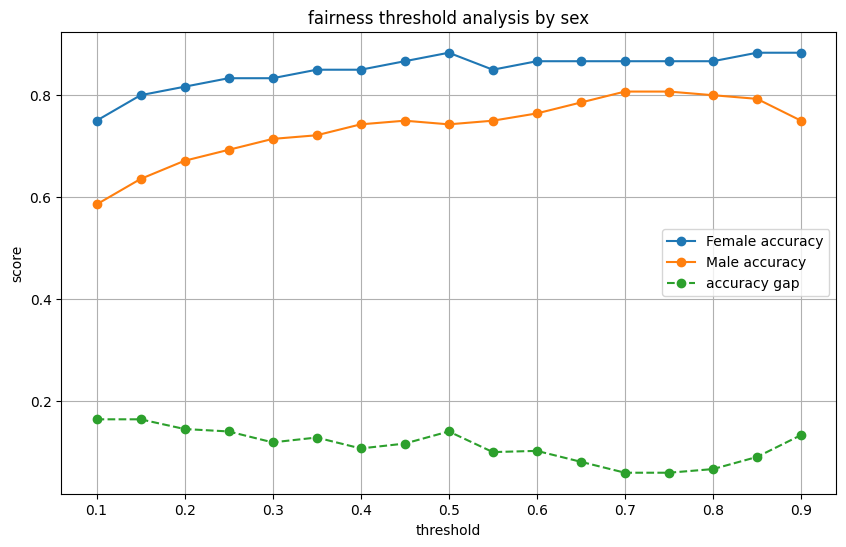

In [36]:
# plot threshold trends
plt.figure(figsize=(10, 6))

for group in sex_groups:
    plt.plot(
        sex_threshold_df['threshold'],
        sex_threshold_df[f'{group}_accuracy'],
        marker='o',
        label=f'{group} accuracy',
    )

if 'accuracy_gap' in sex_threshold_df.columns:
    plt.plot(
        sex_threshold_df['threshold'],
        sex_threshold_df['accuracy_gap'],
        marker='o',
        linestyle='--',
        label='accuracy gap',
    )

plt.xlabel('threshold')
plt.ylabel('score')
plt.title('fairness threshold analysis by sex')
plt.grid(True)
plt.legend()
plt.show()


### Interpretation: Fairness Threshold Plot

The plot shows that group curves are not perfectly aligned across thresholds. This indicates that threshold choice can increase or reduce disparity, so threshold tuning should consider both performance and fairness.
